<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/ML/Decision%20tree%20and%20Random%20Forest/hw1_Alexander_Egorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Домашнее-задание-(10-баллов)" data-toc-modified-id="Домашнее-задание-(10-баллов)-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Домашнее задание (10 баллов)</a></span><ul class="toc-item"><li><span><a href="#Custom-+-Sklearn" data-toc-modified-id="Custom-+-Sklearn-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Custom + Sklearn</a></span></li><li><span><a href="#XGB" data-toc-modified-id="XGB-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>XGB</a></span></li><li><span><a href="#LGB" data-toc-modified-id="LGB-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>LGB</a></span></li></ul></li></ul></div>

 Выполнил: Александр Егоров

# Домашнее задание (10 баллов)

1. (2 балла) Закончить реализацию `ClassificationDecisionTree` в decision_tree (реализовать feature_importance_, проверить корректность predict) и `RandomForestClassifier` в random_forest (predict/predict_proba). Обратите внимение, что в random_forest в качестве `base_estimator` предполагается использовать `DecisionTreeClassifier` из sklearn, использовать вашу реализацию решающего дерева необязательно. <br> Запуск тестов
- `python -m unittest discover sem_dt_rf/decision_tree/tests`
- `python -m unittest discover sem_dt_rf/random_forest/tests`


2. (1 балл) Для регрессионного дерева необходимо использовать такой критерий:
    $$H(R) = \min_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$
    
    Докажите, что минимум H(R) достигается при $c$:

    $$ c = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$$

**Решение**:

Берем производную по c $H(R)^{'} = (\frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2)^{'} = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} -2(y_j-c) = 0 $ отсюда следует, что

$c_{opt} = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$

3. (3 балла) Реализуйте регрессионное дерево. В качестве критерия необходимо использовать критерий, определённый в пункте 2. В качестве функции выдачи результатов необходимо использовать среднее значение ответов по всем объектам в листе.

    Сгенерируйте однопризнаковую выборку для тестирования дерева и покажите работу дерева на этой выборке (пример см. ниже, можно использовать свою версию). Отобразите на одном графике значения алгоритма и точки. Что меняется при изменении параметра глубины? Сделайте выводы.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# generate example
x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)

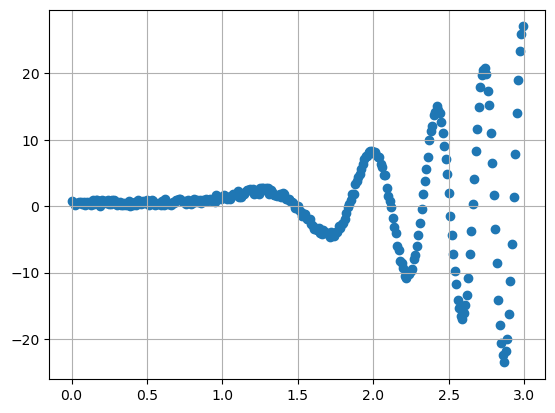

In [ ]:
plt.scatter(x, y)
plt.grid()
plt.show()

**Решение**:

In [ ]:
import sys
sys.path.extend(['H:']) # change your path

from sem_dt_rf.decision_tree.decision_tree import RegressionDecisionTree

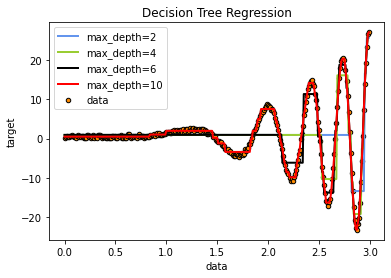

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)
x = x[:, np.newaxis]

some_tree_2 = RegressionDecisionTree(max_depth=2, min_leaf_size=1)
some_tree_2.fit(x, y)
predictions_2 = some_tree_2.predict(x)

some_tree_4 = RegressionDecisionTree(max_depth=4, min_leaf_size=1)
some_tree_4.fit(x, y)
predictions_4 = some_tree_4.predict(x)

some_tree_6 = RegressionDecisionTree(max_depth=6, min_leaf_size=1)
some_tree_6.fit(x, y)
predictions_6 = some_tree_6.predict(x)

some_tree_10 = RegressionDecisionTree(max_depth=10, min_leaf_size=1)
some_tree_10.fit(x, y)
predictions_10 = some_tree_10.predict(x)

plt.figure()
plt.scatter(x, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(x, predictions_2, color="cornflowerblue",
         label="max_depth=2", linewidth=2)
plt.plot(x, predictions_4, color="yellowgreen", label="max_depth=4", linewidth=2)
plt.plot(x, predictions_6, color="black", label="max_depth=6", linewidth=2)
plt.plot(x, predictions_10, color="red", label="max_depth=10", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

При увеличении глубины дерева растет "подгонка" под примеры из обучающей выборки. Это может приводить к переобучению модели и чрезмерной реакции на шум.

4. (4 балла) Протестируйте различные реализации `random_forest` на `fetch_covtype` датасете (можно загрузить с помощью `sklearn.datasets.fetch_covtype`). Возможно, поможет ноутбук с семинара `ensembles_seminar.ipynb`. Для честного сравнения старайтесь использовать похожий набор гиперпараметров.
- ваша реализация (import `RandomForestClassifier as MyRandomForestClassifier` ниже)
- sklearn https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- lightgbm https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html см. параметр `boosting_type`
- xgboost https://xgboost.readthedocs.io/en/stable/tutorials/rf.html

    Что нужно сделать:
- Разбейте данные на train и test.
- Оцените качество алгоритмов по метрике (balanced_accuracy_score)[https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html]
- Оцените время работы `train` и `predict`
- Сделайте выводы

**Решение**:

In [ ]:
import sys
sys.path.extend(['H:']) # change your path
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier
import numpy as np

from sklearn.datasets import fetch_covtype
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb

cov_type = fetch_covtype()

## Custom + Sklearn

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(cov_type["data"],cov_type["target"],test_size=0.2,train_size=0.8, random_state=1)

rs = RobustScaler()
x_train_rs = rs.fit_transform(x_train)
x_test_rs = rs.transform(x_test)


algo_info={}
import time

sklearn_algorithms = [MyRandomForestClassifier(max_depth=10,
                                       random_state=1,
                                       min_samples_leaf=5),
              SklearnRandomForestClassifier(max_depth=10,random_state=1,
                              min_samples_leaf=5,
                              max_samples=0.9,
                              max_features=0.8,
                              n_estimators=30)]

for algo in sklearn_algorithms:
    start_fit = time.time()
    algo.fit(x_train_rs, y_train)
    finish_fit = time.time()

    start_predict = time.time()
    predictions = algo.predict(x_test_rs)
    finish_predict = time.time()

    algo_info[algo.__class__] = {"balanced_accuracy_score:":round(balanced_accuracy_score(y_test, predictions), 5),
                                "fit_time:":round(finish_fit-start_fit,  2),
                                "predict_time:":round(finish_predict-start_predict,2),}




## XGB

In [ ]:
params = {
    "objective": "multi:softmax",
    'num_class': len(np.unique(cov_type["target"]))+1,
    "num_parallel_tree": 30,
    'max_depth': 10,
    "booster": "gbtree",
    "seed": 1,
    "subsample": .8,
    "eta":1,
}


data = xgb.DMatrix(x_train_rs, label=y_train)

start_fit = time.time()
booster = xgb.train(params, data)
finish_fit = time.time()

data = xgb.DMatrix(x_test_rs)

start_predict = time.time()
predictions = booster.predict(data)
finish_predict = time.time()
algo_info["xgb"] = {"balanced_accuracy_score:":round(balanced_accuracy_score(y_test, predictions), 5),
                    "fit_time:":round(finish_fit-start_fit,  2),
                    "predict_time:":round(finish_predict-start_predict,2),}

In [ ]:
algo_info

{sem_dt_rf.random_forest.random_forest.RandomForestClassifier: {'balanced_accuracy_score:': 0.61433,
  'fit_time:': 91.12,
  'predict_time:': 1.87},
 sklearn.ensemble._forest.RandomForestClassifier: {'balanced_accuracy_score:': 0.65097,
  'fit_time:': 82.63,
  'predict_time:': 0.45},
 'xgb': {'balanced_accuracy_score:': 0.87782,
  'fit_time:': 57.41,
  'predict_time:': 1.0}}

## LGB

In [ ]:
params = {
    'min_data_in_leaf': 5,
    'objective': 'multiclass',
    'num_classes': len(np.unique(cov_type["target"]))+1,
    'max_depth': 10,
    "boosting": "rf",
    "seed": 1,
    "subsample": 0.9,
    "subsample_freq": 1,
    "verbose": -1,
}
data = lgb.Dataset(data=x_train_rs, label=y_train)
start_fit = time.time()
booster = lgb.train(params, train_set=data)
finish_fit = time.time()


start_predict = time.time()
predictions = booster.predict(x_test_rs)

finish_predict = time.time()
algo_info["lgb"] = {"balanced_accuracy_score:":round(balanced_accuracy_score(y_test, np.argmax(predictions, axis=1)), 5),
                    "fit_time:":round(finish_fit-start_fit,  2),
                    "predict_time:":round(finish_predict-start_predict,2),}


In [ ]:
algo_info

{sem_dt_rf.random_forest.random_forest.RandomForestClassifier: {'balanced_accuracy_score:': 0.61433,
  'fit_time:': 91.12,
  'predict_time:': 1.87},
 sklearn.ensemble._forest.RandomForestClassifier: {'balanced_accuracy_score:': 0.65097,
  'fit_time:': 82.63,
  'predict_time:': 0.45},
 'xgb': {'balanced_accuracy_score:': 0.87782,
  'fit_time:': 57.41,
  'predict_time:': 1.0},
 'lgb': {'balanced_accuracy_score:': 0.70989,
  'fit_time:': 4.96,
  'predict_time:': 0.31}}

Вывод:

- Отмечу, что я старался запускать модели на +- одинаковых параметрах и не ставил целью оптимизацию метрики. Хотелось посмотреть именно работу без сильной настройки и померить скорость. Все время дано в секундах.

- Кастомная реализация и sklearn работают +- одинаково, что логично, так как кастомная реализация создавалась по образу sklearn реализации. При этом predict time в sklearn меньше, видимо эта часть у меня сделана неоптимальным образом.

- xgb и lgb реализации ожидаемо показывают прирост метрики на тесте. При этом lgb работает существенно быстрее своих конкурентов. Качество на lgb оказалось  сильно меньше, чем у xgb. Возможно не донастроил какие-то параметры.

